In [3]:
import pandas as pd

laptops = pd.read_csv('laptop_market_intelligence_noisy.csv')
laptops.head()


,Brand,Model,Processor,RAM_GB,Storage_GB,GPU,Screen_Size,Weight_kg,Launch_Year,Customer_Rating,Review_Count,Demand_Index,Competitor_Price,Price
0,MSI,Model_0,Ryzen 5,8.0,2048.0,Integrated,17.3,1.10,2019,4.2,4568.0,20,1372.0,300.00
1,Apple,Model_1,Ryzen 9,8.0,128.0,Integrated,14.0,1.95,2023,3.0,3917.0,72,1784.0,300.00
2,Asus,Model_2,i3,64.0,128.0,NVIDIA RTX 3050,17.3,2.79,2018,4.0,817.0,79,1383.0,300.00
3,MSI,Model_3,i7,8.0,512.0,NVIDIA RTX 3060,14.0,3.05,2022,3.2,196.0,53,1911.0,315.75
4,Lenovo,Model_4,i5,32.0,1024.0,NVIDIA RTX 3080,17.3,2.91,2021,4.2,4837.0,23,751.0,317.27


In [7]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             500 non-null    object 
 1   Model             500 non-null    object 
 2   Processor         475 non-null    object 
 3   RAM_GB            475 non-null    float64
 4   Storage_GB        475 non-null    float64
 5   GPU               475 non-null    object 
 6   Screen_Size       500 non-null    float64
 7   Weight_kg         500 non-null    float64
 8   Launch_Year       500 non-null    int64  
 9   Customer_Rating   475 non-null    float64
 10  Review_Count      475 non-null    float64
 11  Demand_Index      500 non-null    int64  
 12  Competitor_Price  475 non-null    float64
 13  Price             500 non-null    float64
dtypes: float64(8), int64(2), object(4)
memory usage: 54.8+ KB


In [8]:
laptops.describe()

,RAM_GB,Storage_GB,Screen_Size,Weight_kg,Launch_Year,Customer_Rating,Review_Count,Demand_Index,Competitor_Price,Price
count,475.000000,475.000000,500.000000,500.000000,500.000000,475.000000,475.000000,500.000000,475.000000,500.000000
mean,27.730526,801.414737,15.241400,1.878900,2020.910000,3.737053,2583.907368,58.564000,1683.477895,980.643660
std,55.663196,705.254075,1.425036,0.652579,2.023385,0.720624,1504.973304,22.990324,759.698658,8608.595383
min,-8.000000,128.000000,13.300000,0.580000,2018.000000,2.500000,21.000000,20.000000,401.000000,5.000000
25%,8.000000,256.000000,14.000000,1.350000,2019.000000,3.100000,1211.500000,38.000000,1017.500000,300.000000
50%,16.000000,512.000000,15.600000,1.760000,2021.000000,3.700000,2562.000000,59.000000,1642.000000,300.000000
75%,32.000000,1024.000000,16.000000,2.375000,2023.000000,4.400000,3990.500000,78.000000,2351.500000,371.882500
max,1024.000000,2048.000000,17.300000,3.420000,2024.000000,5.000000,4997.000000,99.000000,2991.000000,150000.000000


In [9]:
laptops.isnull().sum()

Brand                0
Model                0
Processor           25
RAM_GB              25
Storage_GB          25
GPU                 25
Screen_Size          0
Weight_kg            0
Launch_Year          0
Customer_Rating     25
Review_Count        25
Demand_Index         0
Competitor_Price    25
Price                0
dtype: int64

In [10]:
laptops.duplicated().sum()

np.int64(0)

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def detect_outliers_all(df, z_thresh=3, show_plots=True):
    """
    Detect outliers in all numeric columns of a DataFrame using IQR & Z-score.
    
    Parameters:
        df (pd.DataFrame): The dataframe
        z_thresh (float): Z-score threshold (default=3)
        show_plots (bool): Whether to show boxplot & histogram for each column
    
    Returns:
        dict: summary with outlier counts & indices per column
    """
    results = {}
    num_cols = df.select_dtypes(include=[np.number]).columns

    for col in num_cols:
        series = df[col].dropna()

        # ---- IQR Method ----
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        iqr_outliers = series[(series < lower_bound) | (series > upper_bound)]

        # ---- Z-Score Method ----
        z_scores = np.abs(stats.zscore(series))
        z_outliers = series[z_scores > z_thresh]

        # ---- Visualization ----
        if show_plots:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            
            # Boxplot
            axes[0].boxplot(series)
            axes[0].set_title(f"Boxplot of {col}")
            
            # Histogram
            axes[1].hist(series, bins=30)
            axes[1].set_title(f"Histogram of {col}")
            
            plt.suptitle(f"Outlier check for {col}")
            plt.show()

        # Save results
        results[col] = {
            "IQR_outliers_count": len(iqr_outliers),
            "IQR_outlier_indices": iqr_outliers.index.tolist(),
            "Z_outliers_count": len(z_outliers),
            "Z_outlier_indices": z_outliers.index.tolist()
        }

    return results


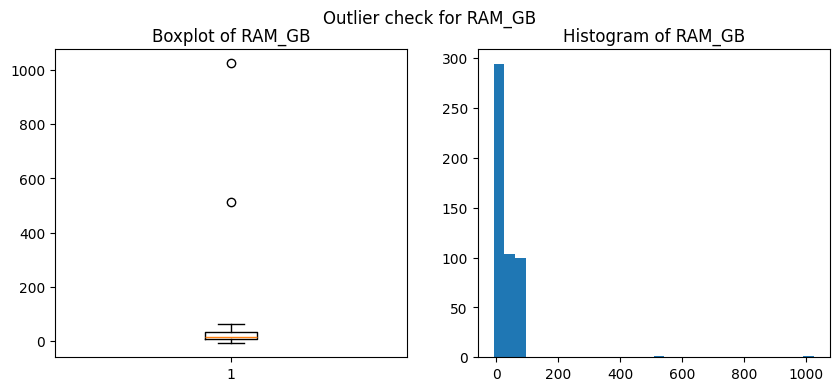

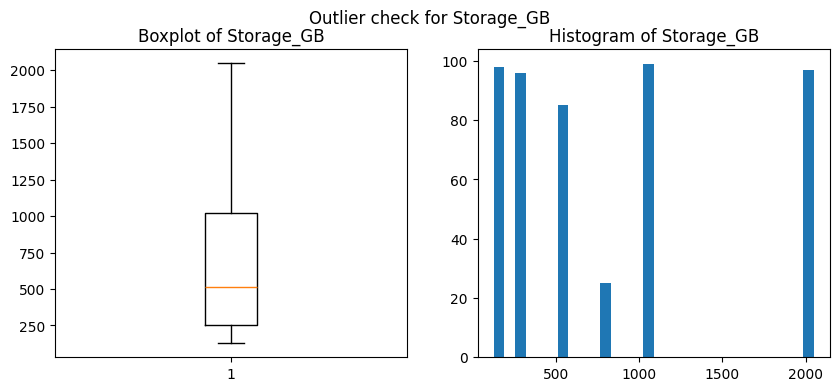

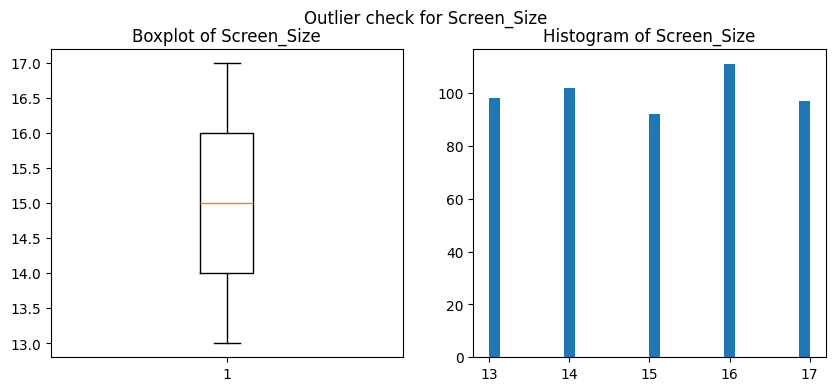

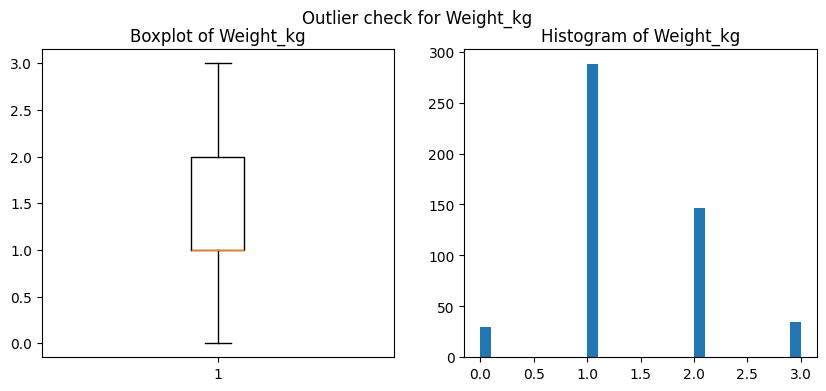

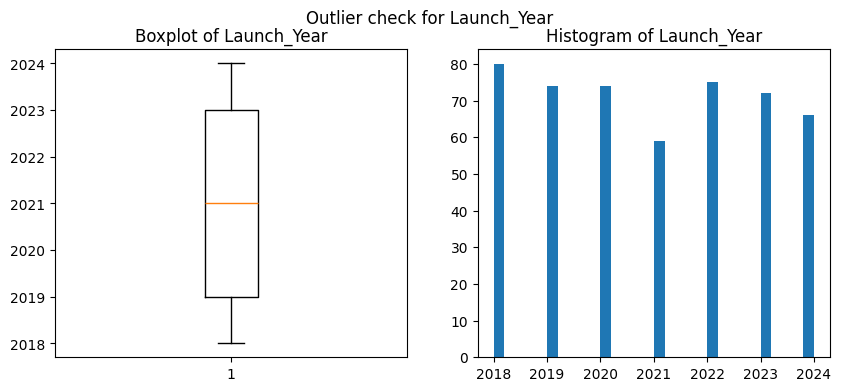

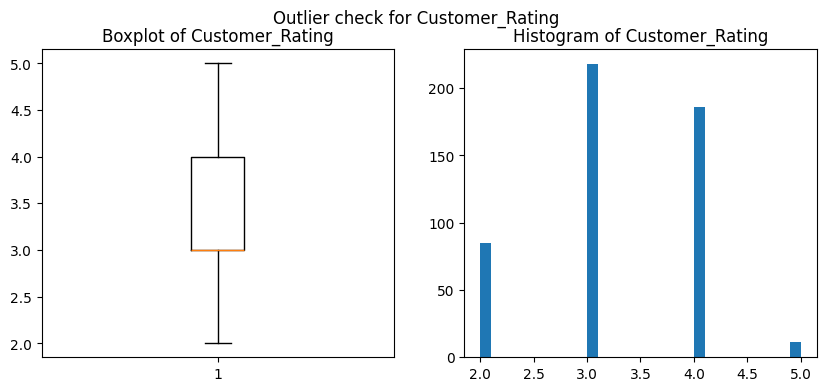

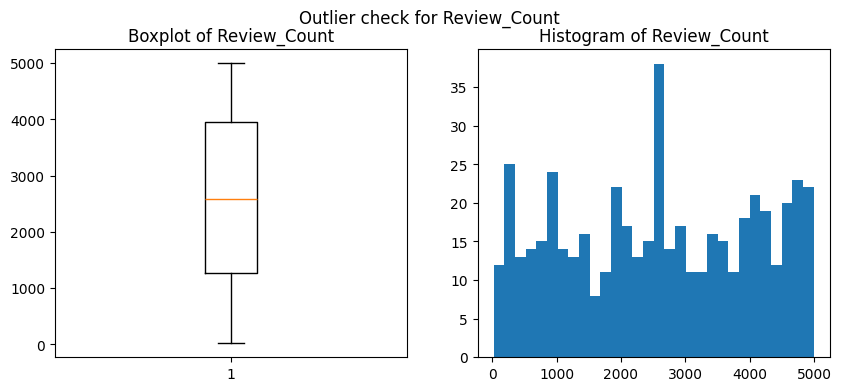

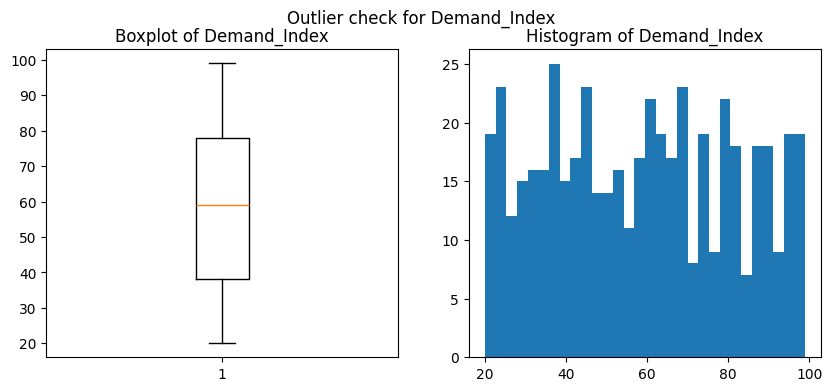

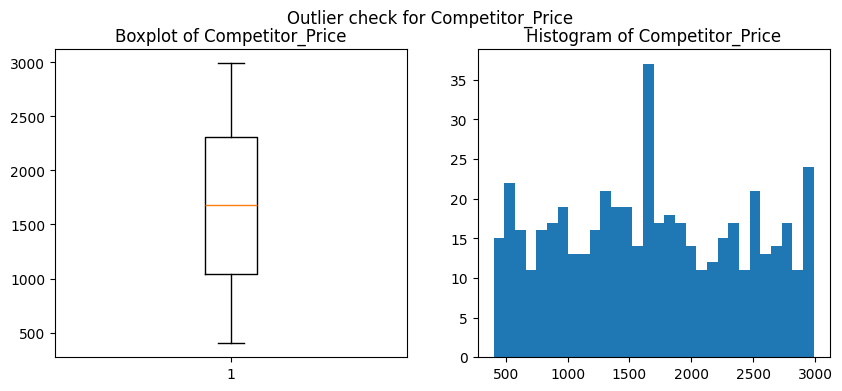

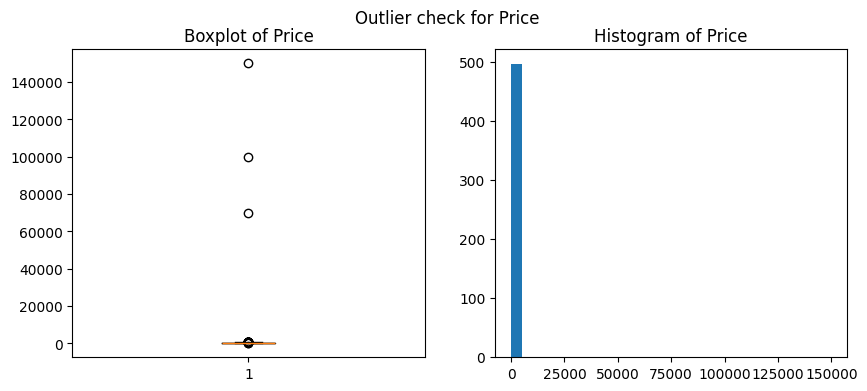


Column: RAM_GB
  IQR outliers: 2
  Z-score outliers: 2

Column: Storage_GB
  IQR outliers: 0
  Z-score outliers: 0

Column: Screen_Size
  IQR outliers: 0
  Z-score outliers: 0

Column: Weight_kg
  IQR outliers: 0
  Z-score outliers: 0

Column: Launch_Year
  IQR outliers: 0
  Z-score outliers: 0

Column: Customer_Rating
  IQR outliers: 0
  Z-score outliers: 0

Column: Review_Count
  IQR outliers: 0
  Z-score outliers: 0

Column: Demand_Index
  IQR outliers: 0
  Z-score outliers: 0

Column: Competitor_Price
  IQR outliers: 0
  Z-score outliers: 0

Column: Price
  IQR outliers: 37
  Z-score outliers: 3


In [30]:
outlier_report = detect_outliers_all(laptops, z_thresh=3, show_plots=True)

# Print summary
for col, info in outlier_report.items():
    print(f"\nColumn: {col}")
    print(f"  IQR outliers: {info['IQR_outliers_count']}")
    print(f"  Z-score outliers: {info['Z_outliers_count']}")


In [31]:
import pandas as pd

# Select only numerical columns
num_cols = laptops.select_dtypes(include=['int64', 'float64']).columns

# Make a copy to avoid changing the original
laptops_no_outliers = laptops.copy()

for col in num_cols:
    Q1 = laptops_no_outliers[col].quantile(0.25)
    Q3 = laptops_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    laptops_no_outliers = laptops_no_outliers[
        (laptops_no_outliers[col] >= lower_bound) & 
        (laptops_no_outliers[col] <= upper_bound)
    ]

print("Before:", laptops.shape)
print("After:", laptops_no_outliers.shape)


Before: (500, 14)
After: (461, 14)


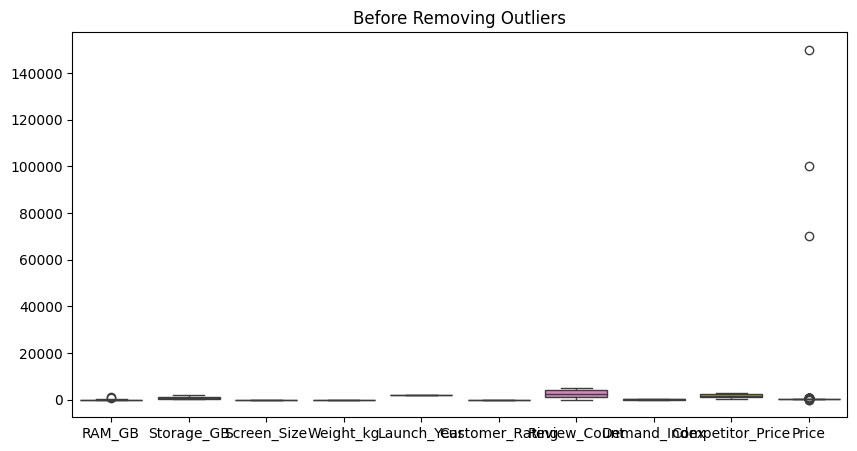

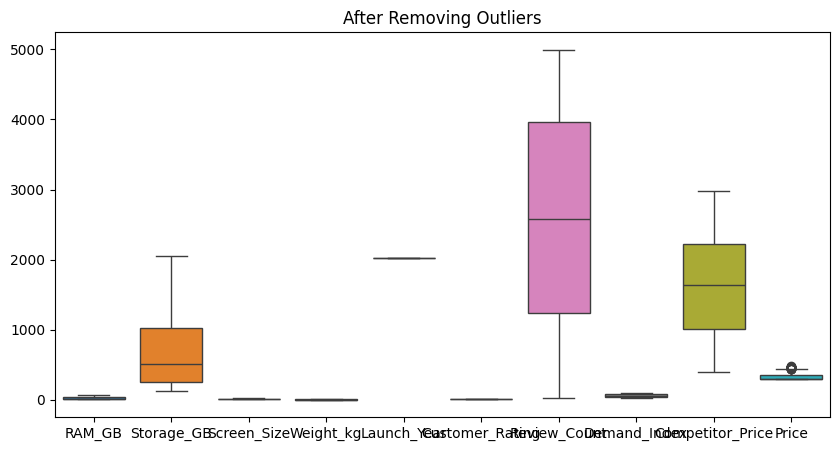

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=laptops[num_cols])
plt.title("Before Removing Outliers")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=laptops_no_outliers[num_cols])
plt.title("After Removing Outliers")
plt.show()


In [33]:
from sklearn.impute import SimpleImputer
import pandas as pd

categorical_cols = laptops.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
laptops[categorical_cols] = categorical_imputer.fit_transform(laptops[categorical_cols])

print(laptops[categorical_cols].isnull().sum())


Brand        0
Model        0
Processor    0
GPU          0
dtype: int64


In [34]:
from sklearn.impute import SimpleImputer
import pandas as pd

numerical_cols = laptops.select_dtypes(include=['int64','float64']).columns
numerical_imputer = SimpleImputer(strategy='mean')
laptops[numerical_cols] = numerical_imputer.fit_transform(laptops[numerical_cols])


laptops[numerical_cols] = laptops[numerical_cols].astype('int64')

print(laptops[numerical_cols].isnull().sum())

RAM_GB              0
Storage_GB          0
Screen_Size         0
Weight_kg           0
Launch_Year         0
Customer_Rating     0
Review_Count        0
Demand_Index        0
Competitor_Price    0
Price               0
dtype: int64


In [35]:
laptops

,Brand,Model,Processor,RAM_GB,Storage_GB,GPU,Screen_Size,Weight_kg,Launch_Year,Customer_Rating,Review_Count,Demand_Index,Competitor_Price,Price
0,MSI,Model_0,Ryzen 5,8,2048,Integrated,17,1,2019,4,4568,20,1372,300
1,Apple,Model_1,Ryzen 9,8,128,Integrated,14,1,2023,3,3917,72,1784,300
2,Asus,Model_2,i3,64,128,NVIDIA RTX 3050,17,2,2018,4,817,79,1383,300
3,MSI,Model_3,i7,8,512,NVIDIA RTX 3060,14,3,2022,3,196,53,1911,315
4,Lenovo,Model_4,i5,32,1024,NVIDIA RTX 3080,17,2,2021,4,4837,23,751,317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,MSI,Model_495,i3,27,801,NVIDIA RTX 3060,13,1,2018,3,2583,55,1683,404
496,Lenovo,Model_496,Ryzen 5,4,1024,NVIDIA RTX 3050,16,1,2023,3,3387,27,2991,502
497,Apple,Model_497,i9,8,2048,Integrated,17,2,2022,3,4847,98,2169,306
498,Dell,Model_498,i7,16,128,NVIDIA RTX 3070,14,2,2021,4,4925,22,424,300


In [36]:
laptops['Launch_Year'] = pd.to_numeric(laptops['Launch_Year'], errors='coerce')


In [ ]:
# Remove non-numeric characters (like 'GB', '$', etc.) and convert
cols_to_numeric = ['RAM_GB', 'Storage_GB', 'Competitor_Price', 'Price']

for col in cols_to_numeric:
    laptops[col] = (
        laptops[col]
        .astype(str)                         
        .str.replace(r'[^0-9.]', '', regex=True)  
    )
    laptops[col] = pd.to_numeric(laptops[col], errors='coerce')


In [38]:
print(laptops[cols_to_numeric].dtypes)
print(laptops['Launch_Year'].dtype)


RAM_GB              int64
Storage_GB          int64
Competitor_Price    int64
Price               int64
dtype: object
int64


In [40]:
laptops_no_outliers['Price_per_GB']= laptops_no_outliers['Price'] / laptops_no_outliers['Storage_GB'].replace(0, np.nan)
print(laptops_no_outliers[['Price', 'Storage_GB', 'Price_per_GB']].head())

   Price  Storage_GB  Price_per_GB
0    300        2048      0.146484
1    300         128      2.343750
2    300         128      2.343750
3    315         512      0.615234
4    317        1024      0.309570


In [44]:
laptops_no_outliers['Performance_Index']= laptops_no_outliers['RAM_GB'] * laptops_no_outliers['Customer_Rating'] * laptops_no_outliers['Demand_Index']
print(laptops_no_outliers[['RAM_GB','Customer_Rating','Demand_Index','Performance_Index']].head())

   RAM_GB  Customer_Rating  Demand_Index  Performance_Index
0       8                4            20                640
1       8                3            72               1728
2      64                4            79              20224
3       8                3            53               1272
4      32                4            23               2944


In [46]:
laptops_no_outliers['Discount_Factor'] = laptops_no_outliers['Competitor_Price'] - laptops_no_outliers['Price']
print(laptops_no_outliers[['Competitor_Price', 'Price', 'Discount_Factor']].head())

   Competitor_Price  Price  Discount_Factor
0              1372    300             1072
1              1784    300             1484
2              1383    300             1083
3              1911    315             1596
4               751    317              434


In [57]:
laptops_no_outliers['Launch_Category'] = pd.cut(
    laptops_no_outliers['Launch_Year'].astype(int), 
    bins=[0, 2020, 2022, float('inf')],   
    labels=['Old', 'Mid', 'New']          
)
print(laptops_no_outliers[['Launch_Year', 'Launch_Category']].head())

   Launch_Year Launch_Category
0         2019             Old
1         2023             New
2         2018             Old
3         2022             Mid
4         2021             Mid


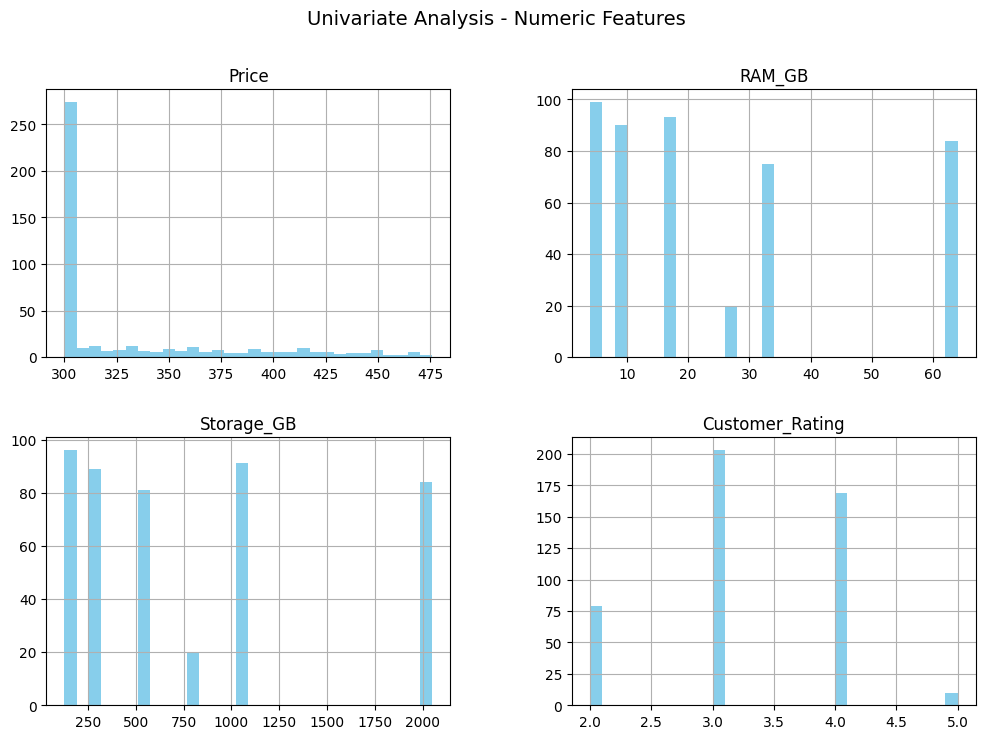

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Price", "RAM_GB", "Storage_GB", "Customer_Rating"]
laptops_no_outliers[numeric_cols].hist(bins=30, figsize=(12,8), color="skyblue")
plt.suptitle("Univariate Analysis - Numeric Features", fontsize=14)
plt.show()

C:\Users\ENVY\AppData\Local\Temp\ipykernel_22464\911726792.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=laptops_no_outliers, x=col, palette="Set2")
C:\Users\ENVY\AppData\Local\Temp\ipykernel_22464\911726792.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=laptops_no_outliers, x=col, palette="Set2")
C:\Users\ENVY\AppData\Local\Temp\ipykernel_22464\911726792.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=laptops_no_outliers, x=col, palette="Set2")


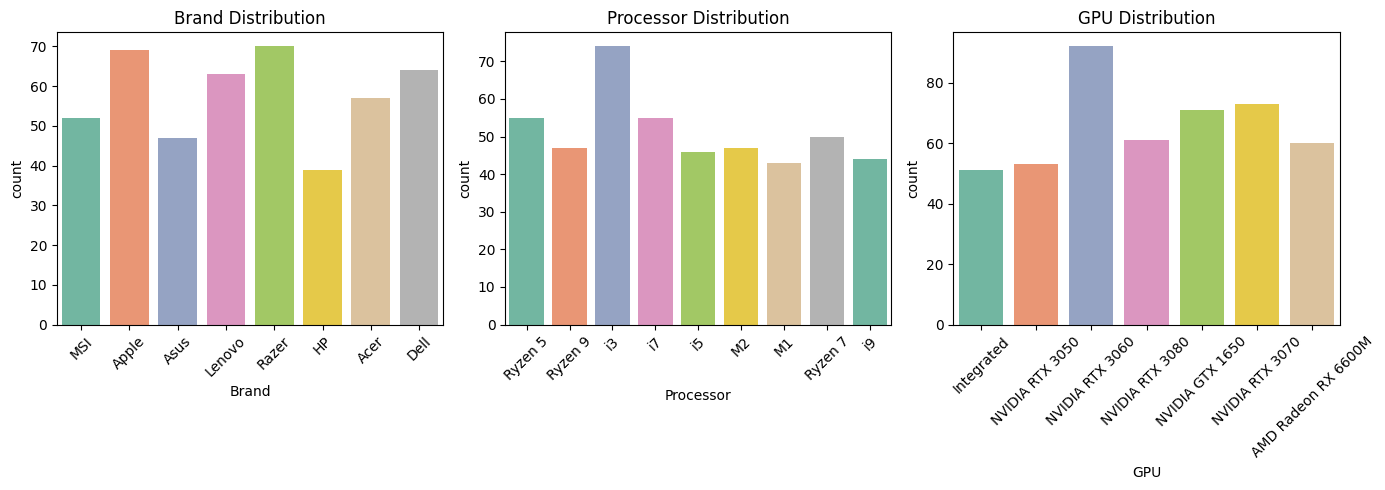

In [64]:
categorical_cols = ["Brand", "Processor", "GPU"]
plt.figure(figsize=(14,5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=laptops_no_outliers, x=col, palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

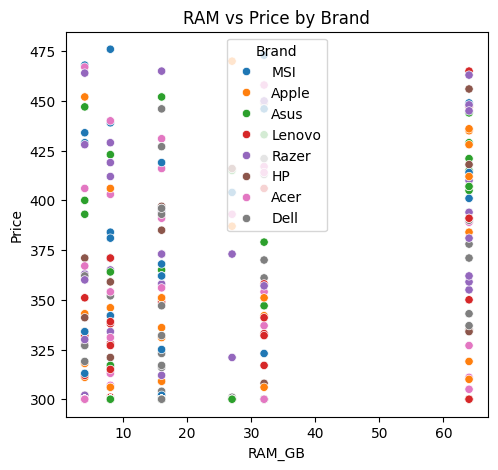

In [66]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(data=laptops_no_outliers, x='RAM_GB', y='Price', hue='Brand')
plt.title("RAM vs Price by Brand")
plt.show()

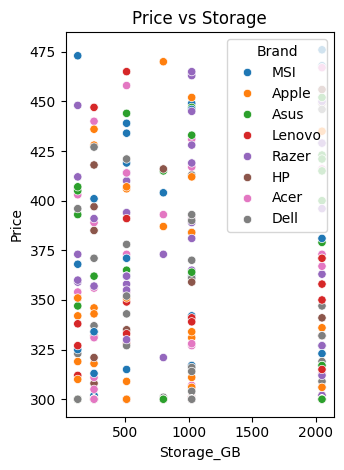

In [67]:
plt.subplot(1,2,2)
sns.scatterplot(data=laptops_no_outliers, x="Storage_GB", y="Price", hue="Brand")
plt.title("Price vs Storage")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Price vs RAM')

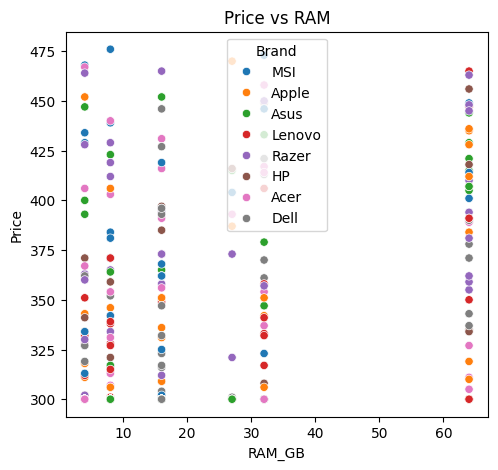

In [78]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(data=laptops_no_outliers, x="RAM_GB", y="Price", hue="Brand")
plt.title("Price vs RAM")

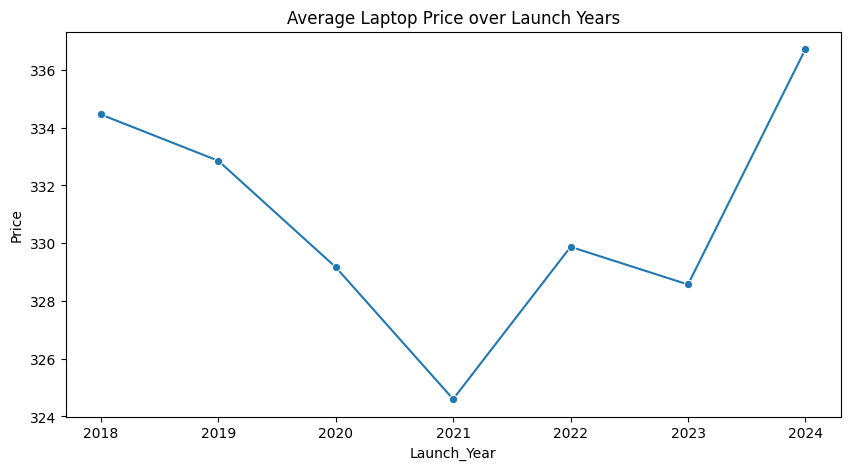

In [69]:
avg_price_year = laptops_no_outliers.groupby("Launch_Year")["Price"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=avg_price_year, x="Launch_Year", y="Price", marker="o")
plt.title("Average Laptop Price over Launch Years")
plt.show()

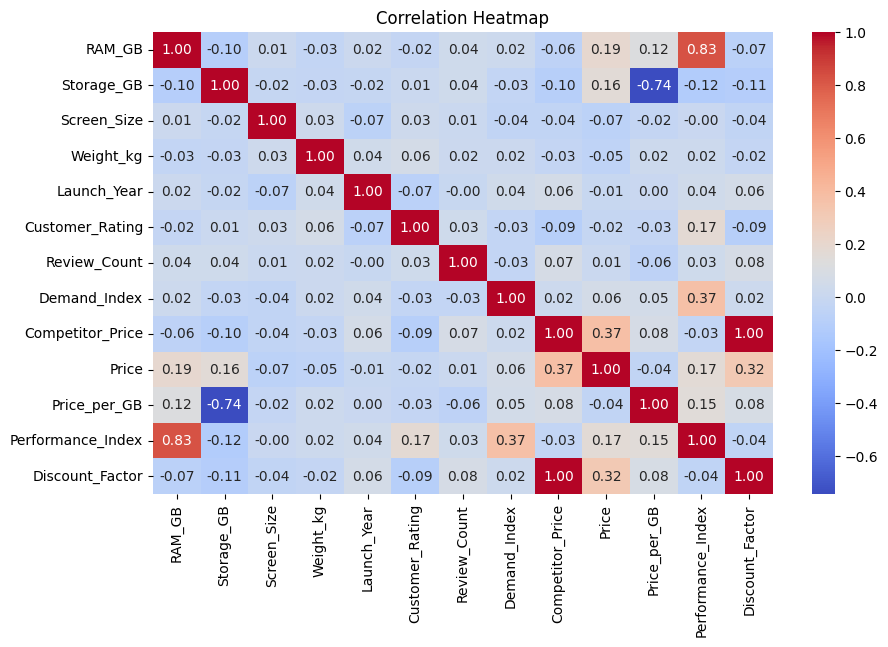

In [70]:
plt.figure(figsize=(10,6))
sns.heatmap(laptops_no_outliers.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

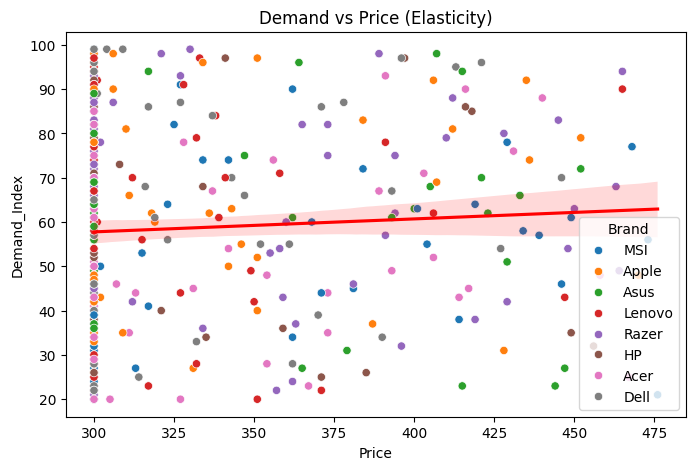

In [72]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=laptops_no_outliers, x="Price", y="Demand_Index", hue="Brand")
sns.regplot(data=laptops_no_outliers, x="Price", y="Demand_Index", scatter=False, color="red")
plt.title("Demand vs Price (Elasticity)")
plt.show()

In [73]:
if "Units_Sold" in laptops_no_outliers.columns:
    plt.figure(figsize=(8,5))
    sns.regplot(data=laptops_no_outliers, x="Price", y="Units_Sold", scatter_kws={"alpha":0.5})
    plt.title("Price vs Units Sold")
    plt.show()

C:\Users\ENVY\AppData\Local\Temp\ipykernel_22464\119238815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_brand.index, y=avg_price_brand.values, palette="Set3")


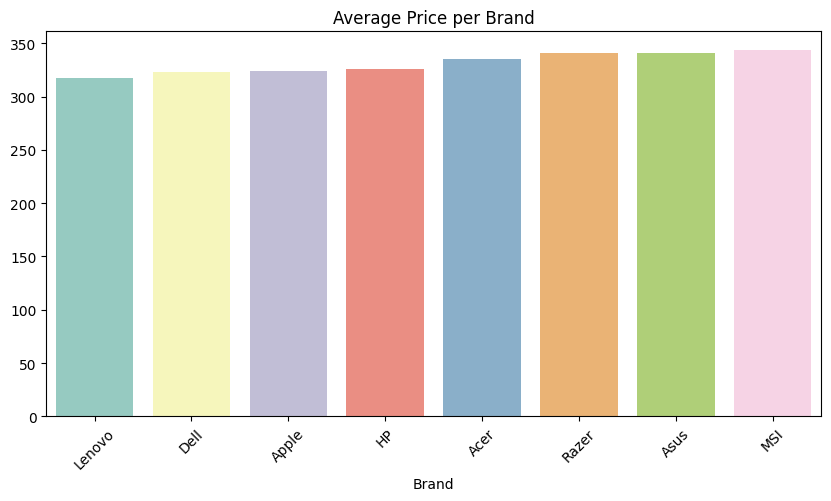

In [74]:
avg_price_brand = laptops_no_outliers.groupby("Brand")["Price"].mean().sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=avg_price_brand.index, y=avg_price_brand.values, palette="Set3")
plt.xticks(rotation=45)
plt.title("Average Price per Brand")
plt.show()

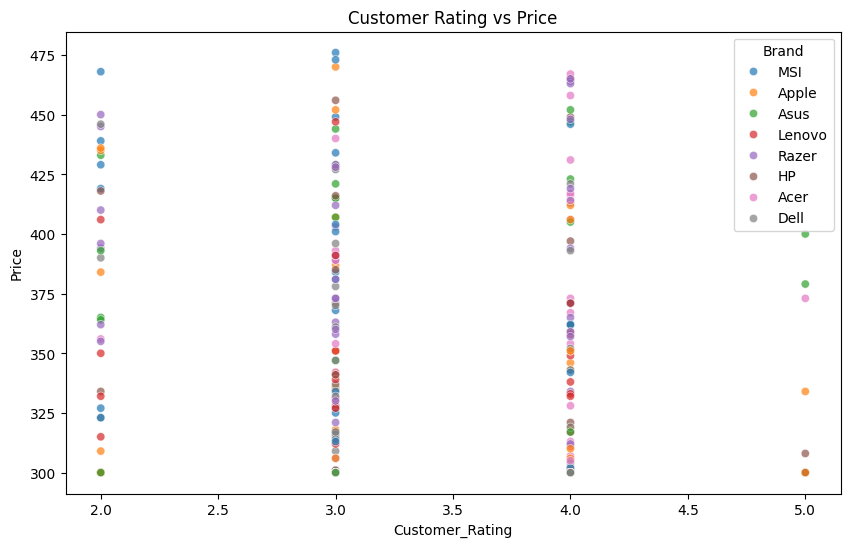

In [75]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=laptops_no_outliers, x="Customer_Rating", y="Price", hue="Brand", alpha=0.7)
plt.title("Customer Rating vs Price")
plt.show()

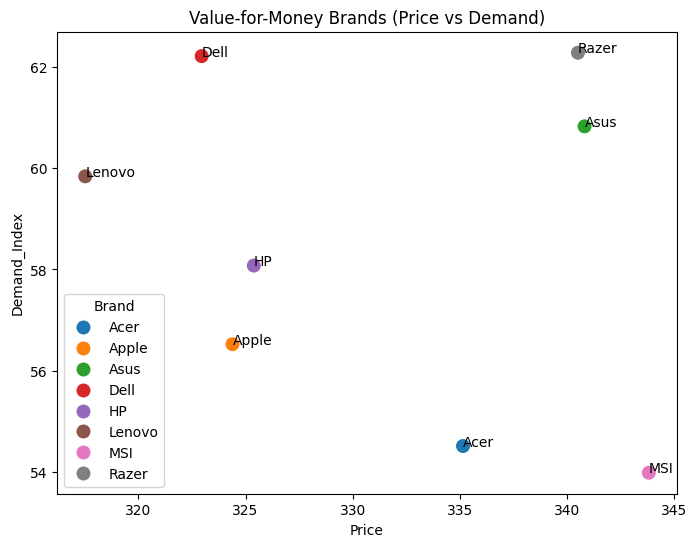

In [76]:
value_brands = laptops_no_outliers.groupby("Brand").agg({
    "Price": "mean",
    "Demand_Index": "mean"
}).reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(data=value_brands, x="Price", y="Demand_Index", hue="Brand", s=120)
for i in range(len(value_brands)):
    plt.text(value_brands["Price"][i], value_brands["Demand_Index"][i], value_brands["Brand"][i])
plt.title("Value-for-Money Brands (Price vs Demand)")
plt.show()

In [79]:
laptops_no_outliers.to_csv("laptop_data_cleaned.csv", index=False)